## Seasonal Agriculture Performance Analysis
# Major Data Analytics Project

**Domain:** Agriculture  
**Project Theme:** Seasonal Agriculture Performance  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  

### Project Goal
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.

> **Important:** This is a Data Analytics project. No Machine Learning or dashboard development is required.

## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed in different seasonal conditions.

The problem is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

## 2. Objective

The primary objective of this project is to analyze agricultural data from different seasons and identify meaningful patterns, trends, relationships and differences in agricultural performance.

Students should independently:
- Explore and understand the dataset
- Clean and prepare the data for analysis
- Examine how agricultural performance varies across seasons
- Identify important seasonal patterns and trends
- Investigate relationships between seasonal conditions and agricultural outcomes
- Apply appropriate statistical and visualization techniques
- Develop meaningful conclusions and data-driven recommendationsm

## 3. Key Questions

- How does agricultural performance vary across seasons?
- What major seasonal patterns can be observed?
- Which characteristics change between seasons?
- Are there noticeable variations in resource usage across seasons?
- Are there relationships between seasonal environmental conditions and agricultural performance?
- How do economic outcomes vary across seasons?
- What insights can be derived from the observed seasonal differences?

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

In [2]:
# Load the dataset
# CSV file aur notebook SAME FOLDER mein honi chahiye
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (4000, 28)


## 4. Initial Data Understanding

In this section we load the dataset and examine its basic structure — shape, columns, data types, and sample records.

In [3]:
# First 5 rows
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [4]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [5]:
# Random sample of records
df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.70,26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [6]:
print("Shape:", df.shape)
print("\nAll columns:")
print(df.columns.tolist())

Shape: (4000, 28)

All columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [7]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

## 5. Variable Classification

Variables in this dataset can be grouped as:
- **Identifier variables** – Farm_ID
- **Categorical variables** – State, District, Crop, Season, Irrigation_Method
- **Numerical variables** – Farm_Area_Hectares, Rainfall_mm, etc.
- **Environmental variables** – Rainfall_mm, Avg_Temperature_C, Humidity_pct, Sunlight_Hours_Day, Soil_pH, Soil_Moisture_pct
- **Operational variables** – Nitrogen_kg_ha, Phosphorus_kg_ha, Potassium_kg_ha, Fertilizer_kg_ha, Pesticide_Litre_ha, Seed_Quality_Score
- **Production/performance variables** – Yield_Tonnes_Ha, Production_Tonnes
- **Economic variables** – Total_Cost_INR, Revenue_INR, Profit_INR, Market_Price_INR_Tonne

**Student task:** The most relevant variables for seasonal performance analysis are environmental variables (rainfall, temperature) and production/economic variables (yield, profit) because they directly measure what changes across seasons.

In [8]:
# Numerical and categorical columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


## 6. Data Cleaning

### 6.1 Duplicate Records
Duplicate records produce incorrect analysis results.
We check and remove any exact duplicate rows.

### 6.2 Data Type Verification  
We verify all columns have correct data types after cleaning.

In [9]:
# Check for duplicate rows
print("Duplicate rows found:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Duplicate rows found: 0
Shape after removing duplicates: (4000, 28)


In [10]:
# Check data types after duplicate removal
df.dtypes

Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

## 7. Missing Value Analysis & Handling

### 7.1 Missing Value Detection
We identify which columns have missing data before deciding how to handle them.

In [11]:
# Missing values per column
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print("Columns with missing values:")
missing_df[missing_df['Missing Count'] > 0]

Columns with missing values:


,Missing Count,Missing %
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


### 7.2 Handling Missing Values

**Strategy chosen: Median Imputation**

**Why median?**
- Missing columns are numerical (Rainfall_mm, Soil_Moisture_pct, Yield_Tonnes_Ha)
- Median is not affected by outliers unlike mean
- We do NOT delete rows — that would reduce our data
- We do NOT fill with zero — that would create false values

In [12]:
# Median imputation for numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"'{col}' filled with median: {median_val:.2f}")

print("\nRemaining missing values:", df.isnull().sum().sum())

'Rainfall_mm' filled with median: 582.00
'Soil_Moisture_pct' filled with median: 26.40
'Yield_Tonnes_Ha' filled with median: 1.74

Remaining missing values: 0


### 7.3 Descriptive Statistical Summary

We compute key statistics for all numerical variables to understand
the range, central tendency and spread of the data.


In [13]:
# Overall statistical summary
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

statistical_summary = pd.DataFrame({
    "Mean":    df[numeric_columns].mean(),
    "Median":  df[numeric_columns].median(),
    "Std_Dev": df[numeric_columns].std(),
    "Min":     df[numeric_columns].min(),
    "Max":     df[numeric_columns].max()
}).round(2)

statistical_summary

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.90,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,1395.20
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [14]:
# Seasonal descriptive summary — mean, median, std per season
season_summary = df.groupby("Season")[numeric_columns].agg(
    ["mean", "median", "std"]
).round(2)

season_summary

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      849.20 853.10 183.69   
Rabi                 7.75   7.68 4.18      437.62 432.20 175.35   
Zaid                 8.09   8.09 4.16      304.65 288.20 157.24   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.15   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.07   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.28   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.10 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.94         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.94         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.18 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.63   1.94 14.39             46.31  13.24 135.70   
Rabi              5.04   1.67 12.75             41.49  11.08 121.90   
Zaid              4.64   1.46 11.27             38.89   9.97 112.00   

       Market_Price_INR_Tonne                   Total_Cost_INR            \
                         mean   median      std           mean    median   
Season                                                                     
Kharif               44850.91 25793.00 30301.56      531804.41 524840.00   
Rabi                 44747.97 26041.00 30309.56      513836.58 506733.00   
Zaid                 44212.03 25749.50 30086.23      543976.73 534833.00   

                 Revenue_INR                     Profit_INR            \
             std        mean    median       std       mean    median   
Season                                                                  
Kharif 298487.69   710719.06 520196.00 708710.37  178914.65  38808.00   
Rabi   288386.89   601526.05 438156.00 584545.52   87689.47  -3187.00   
Zaid   297576.86   519171.90 373700.50 509524.55  -24804.82 -62144.00   

                 Water_Used_m3                 Water_Efficiency_t_per_1000m3  \
      

## 8. Univariate Analysis

Univariate analysis examines each variable independently.
This helps us understand individual distributions before comparing across seasons.


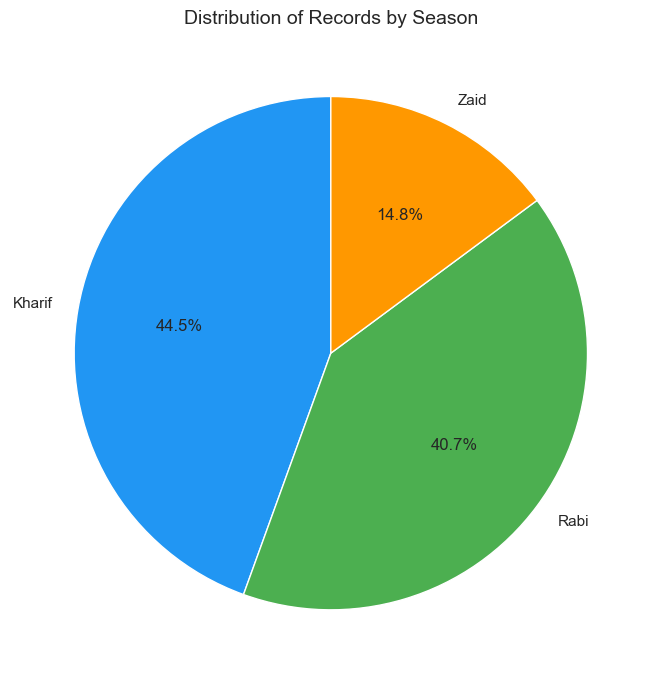

In [15]:
# Season distribution - Pie Chart
plt.figure(figsize=(7, 7))
df['Season'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    colors=['#2196F3', '#4CAF50', '#FF9800']
)
plt.title('Distribution of Records by Season', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.show()

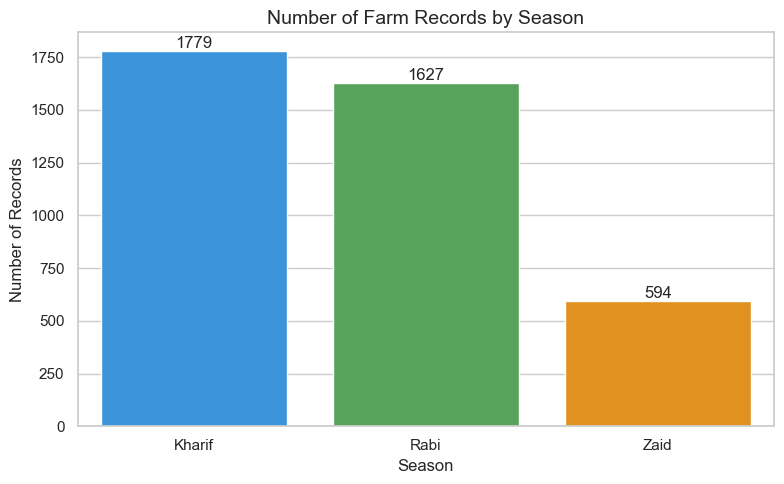

In [37]:
# Season count bar chart
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x="Season",
                    hue="Season", legend=False,
                   order=["Kharif", "Rabi", "Zaid"],
                   palette=["#2196F3", "#4CAF50", "#FF9800"])
plt.title("Number of Farm Records by Season", fontsize=14)
plt.xlabel("Season")
plt.ylabel("Number of Records")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

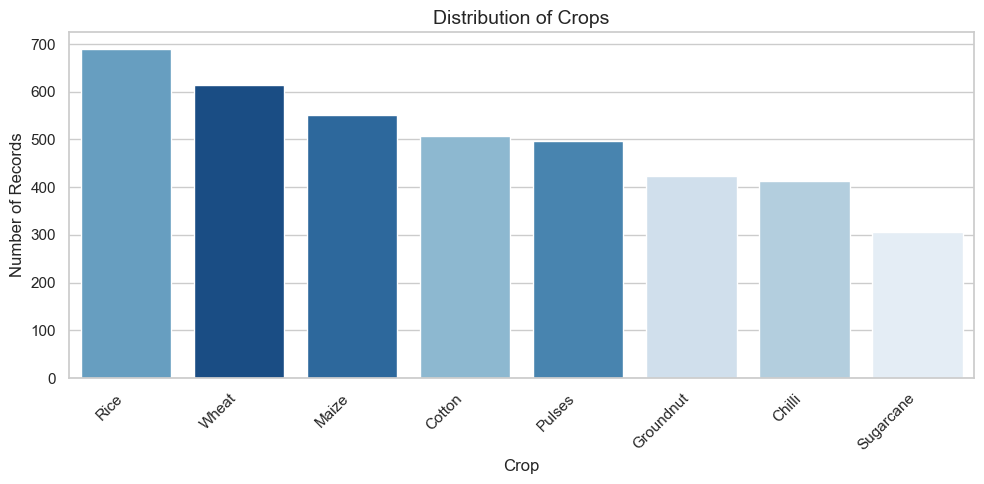

In [31]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Crop", hue="Crop", legend=False,
              order=df["Crop"].value_counts().index,
              palette="Blues_r")
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Crops", fontsize=14)
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

## 9. Outlier Analysis

Outliers are extreme values significantly different from other data points.
We use the IQR (Interquartile Range) method to detect them.

Note: Outliers are NOT automatically deleted.
Each outlier is evaluated as: data-entry error / legitimate value / needs investigation.

In [18]:
# IQR method - detect outliers
outlier_results = []
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    if count > 0:
        outlier_results.append({
            'Column': col,
            'Lower Bound': round(lower, 2),
            'Upper Bound': round(upper, 2),
            'Outlier Count': count,
            'Outlier %': round(count/len(df)*100, 2)
        })

pd.DataFrame(outlier_results)

,Column,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Avg_Temperature_C,15.35,38.15,2,0.05
1,Humidity_pct,29.09,97.59,6,0.15
2,Sunlight_Hours_Day,4.35,10.35,26,0.65
3,Soil_Moisture_pct,7.70,45.30,5,0.12
4,Nitrogen_kg_ha,34.41,205.31,10,0.25
5,Phosphorus_kg_ha,11.40,104.20,16,0.40
6,Potassium_kg_ha,30.10,179.70,32,0.80
7,Fertilizer_kg_ha,19.14,352.04,15,0.38
8,Pesticide_Litre_ha,-0.38,10.46,8,0.20
9,Yield_Tonnes_Ha,-1.62,5.50,302,7.55


### Outlier Decision

| Column | Decision | Reason |
|---|---|---|
| Rainfall_mm | Keep — Legitimate | Rainfall varies naturally by region and year |
| Farm_Area_Hectares | Keep — Legitimate | Farm sizes vary widely |
| Market_Price_INR_Tonne | Keep — Legitimate | Market prices fluctuate seasonally |
| Total_Cost_INR | Keep — Legitimate | Large farms have higher costs naturally |
| Soil_pH | Investigate | Very low/high pH may indicate data collection issues |

**Conclusion:** No outliers removed. All extreme values appear to be real agricultural variations.

## 10. Bivariate Analysis


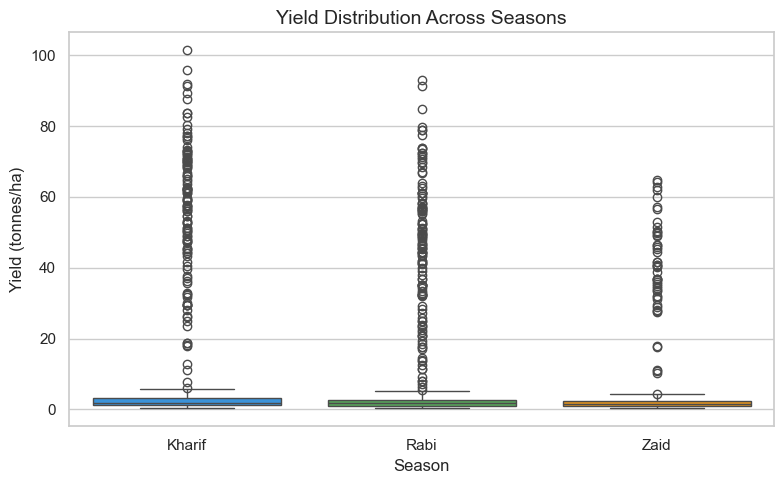

In [32]:
# Season vs Yield
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha",
            order=["Kharif", "Rabi", "Zaid"],
            hue="Season", legend=False,
            palette=["#2196F3", "#4CAF50", "#FF9800"])
plt.title("Yield Distribution Across Seasons", fontsize=14)
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

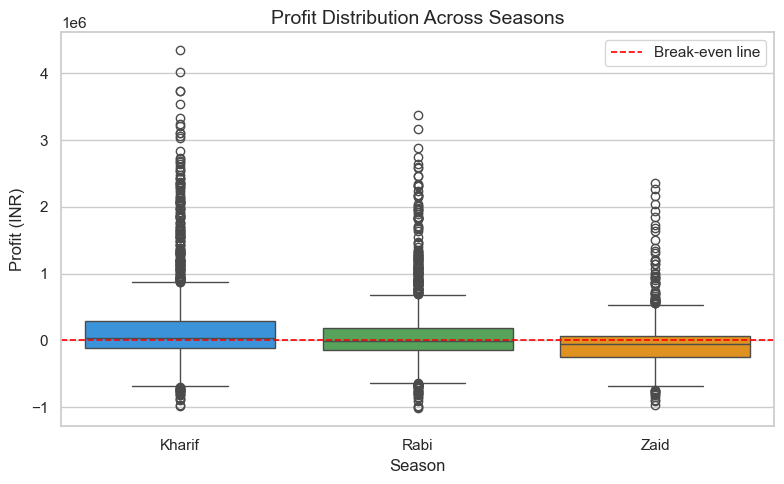

In [33]:
# Season vs Profit (economic outcome)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Profit_INR",
            order=["Kharif", "Rabi", "Zaid"],
            hue="Season", legend=False,
            palette=["#2196F3", "#4CAF50", "#FF9800"])
plt.axhline(0, color='red', linestyle='--', linewidth=1.2, label='Break-even line')
plt.title("Profit Distribution Across Seasons", fontsize=14)
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.legend()
plt.tight_layout()
plt.show()

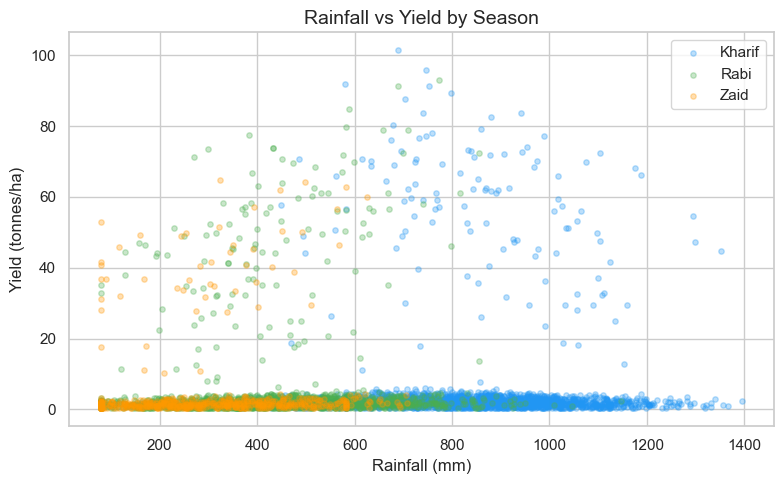

In [21]:
# Rainfall vs Yield — environmental vs performance
plt.figure(figsize=(8, 5))
colors = {"Kharif": "#2196F3", "Rabi": "#4CAF50", "Zaid": "#FF9800"}
for season, grp in df.groupby("Season"):
    plt.scatter(grp["Rainfall_mm"], grp["Yield_Tonnes_Ha"],
                label=season, alpha=0.3, s=15, color=colors[season])
plt.title("Rainfall vs Yield by Season", fontsize=14)
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.legend()
plt.tight_layout()
plt.show()

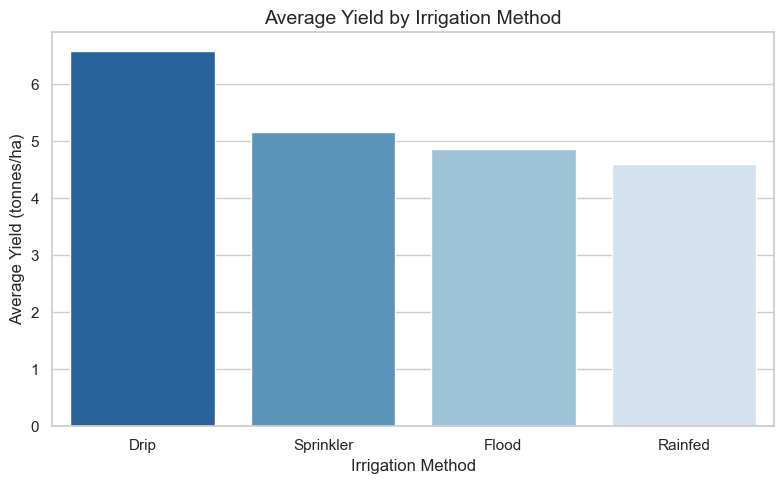

In [34]:
# Irrigation Method vs Yield
plt.figure(figsize=(8, 5))
irr = df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)
sns.barplot(x=irr.index, y=irr.values,
            hue=irr.index, legend=False,
            palette="Blues_r")
plt.title("Average Yield by Irrigation Method", fontsize=14)
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

## 11. Multivariate Analysis

We examine 3+ variables together to find how season interacts 
with other dimensions like crop type, region, and environmental conditions.


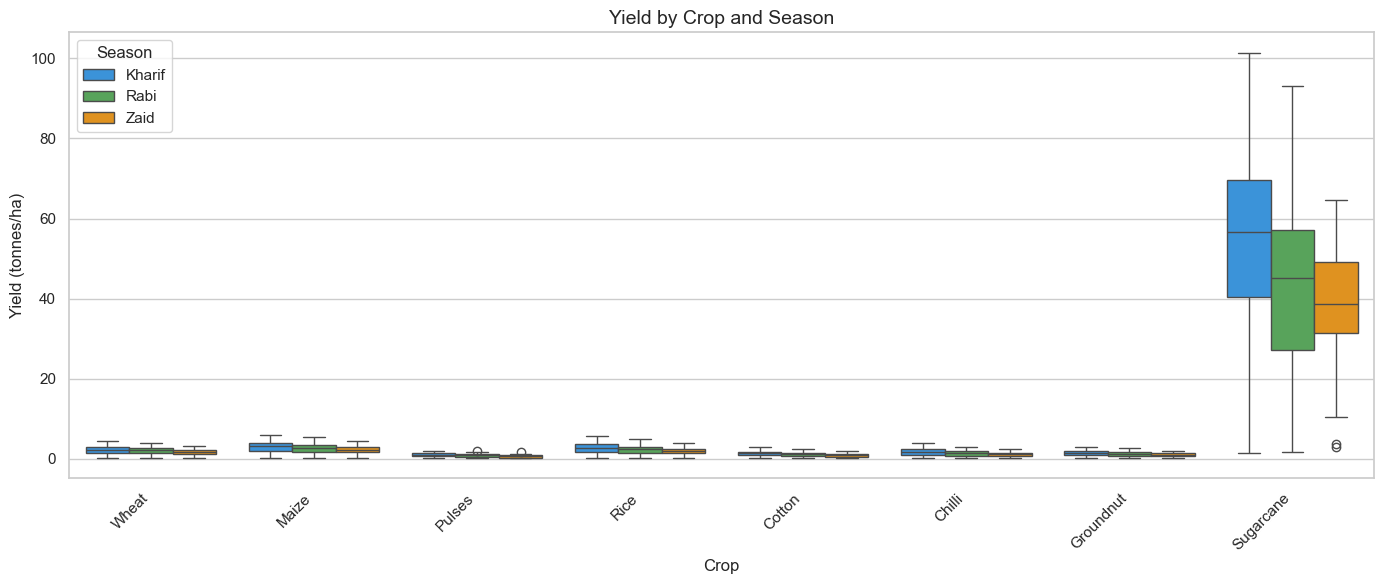

In [23]:
# Crop vs Yield with Season as hue
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season",
            palette=["#2196F3", "#4CAF50", "#FF9800"])
plt.xticks(rotation=45, ha="right")
plt.title("Yield by Crop and Season", fontsize=14)
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

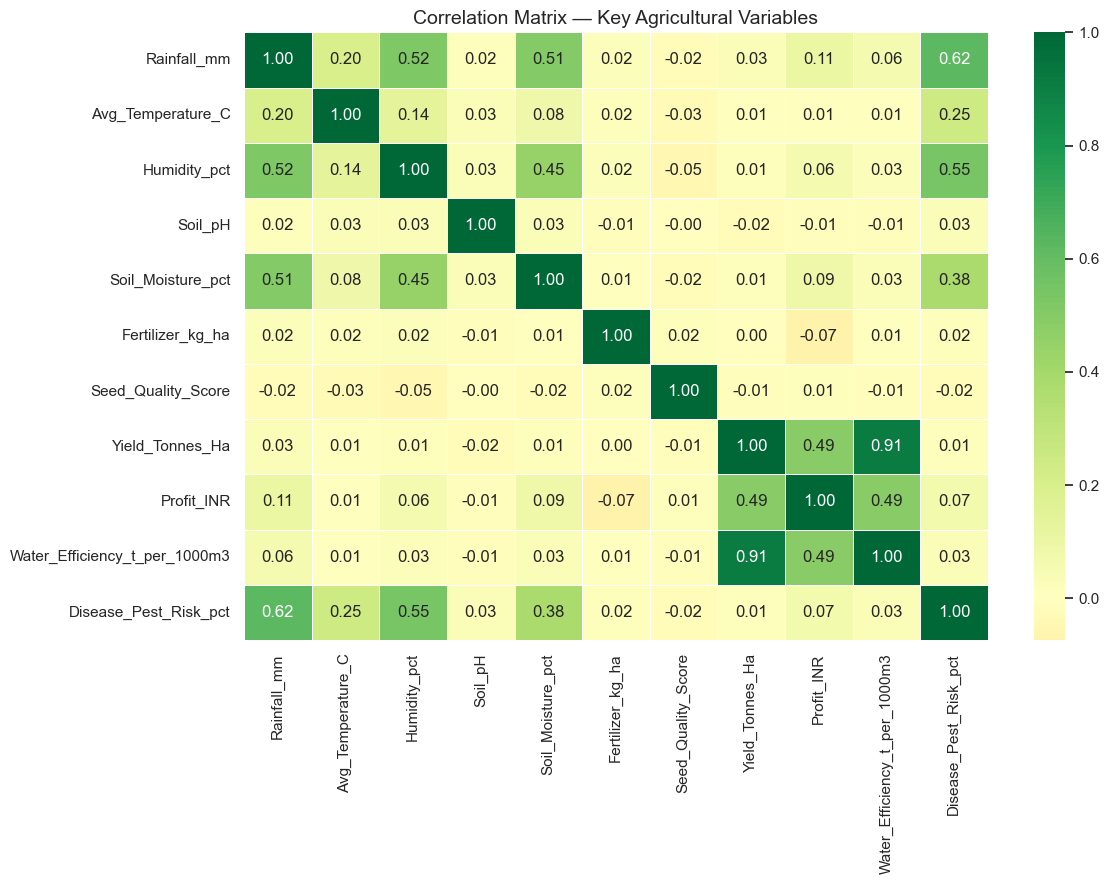

In [24]:
# Correlation Heatmap
key_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
            'Soil_pH', 'Soil_Moisture_pct', 'Fertilizer_kg_ha',
            'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Profit_INR',
            'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

plt.figure(figsize=(12, 9))
sns.heatmap(df[key_cols].corr(), annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, linewidths=0.5)
plt.title("Correlation Matrix — Key Agricultural Variables", fontsize=14)
plt.tight_layout()
plt.show()

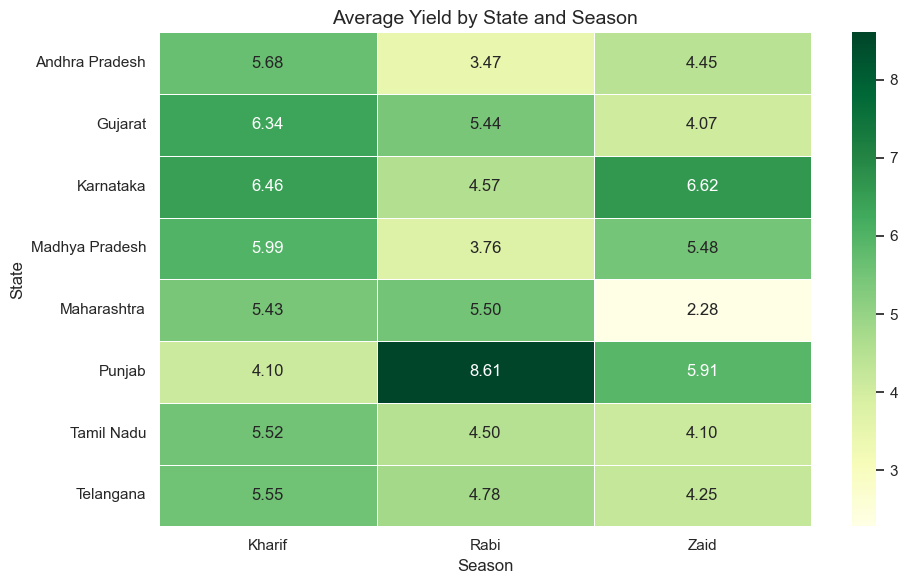

In [25]:
# State vs Season vs Yield — regional consistency check
pivot = df.pivot_table(values='Yield_Tonnes_Ha',
                       index='State', columns='Season', aggfunc='mean').round(2)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGn", linewidths=0.5)
plt.title("Average Yield by State and Season", fontsize=14)
plt.tight_layout()
plt.show()

## 12. Seasonal Comparison


In [26]:
# Complete seasonal summary table
season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Avg_Yield_t_ha=("Yield_Tonnes_Ha", "mean"),
    Total_Production_Tonnes=("Production_Tonnes", "sum"),
    Avg_Profit_INR=("Profit_INR", "mean"),
    Avg_Rainfall_mm=("Rainfall_mm", "mean"),
    Avg_Temperature_C=("Avg_Temperature_C", "mean"),
    Avg_Water_Used_m3=("Water_Used_m3", "mean"),
    Avg_Fertilizer_kg_ha=("Fertilizer_kg_ha", "mean"),
    Avg_Disease_Risk_pct=("Disease_Pest_Risk_pct", "mean")
).round(2)

season_metrics

,Records,Avg_Yield_t_ha,Total_Production_Tonnes,Avg_Profit_INR,Avg_Rainfall_mm,Avg_Temperature_C,Avg_Water_Used_m3,Avg_Fertilizer_kg_ha,Avg_Disease_Risk_pct
Season,,,,,,,,,
Kharif,1779,5.63,82387.61,178914.65,849.20,28.45,6102.20,187.08,54.47
Rabi,1627,5.04,67498.88,87689.47,437.62,23.49,5846.99,185.41,40.48
Zaid,594,4.64,23098.35,-24804.82,304.65,31.04,6419.89,184.64,38.22


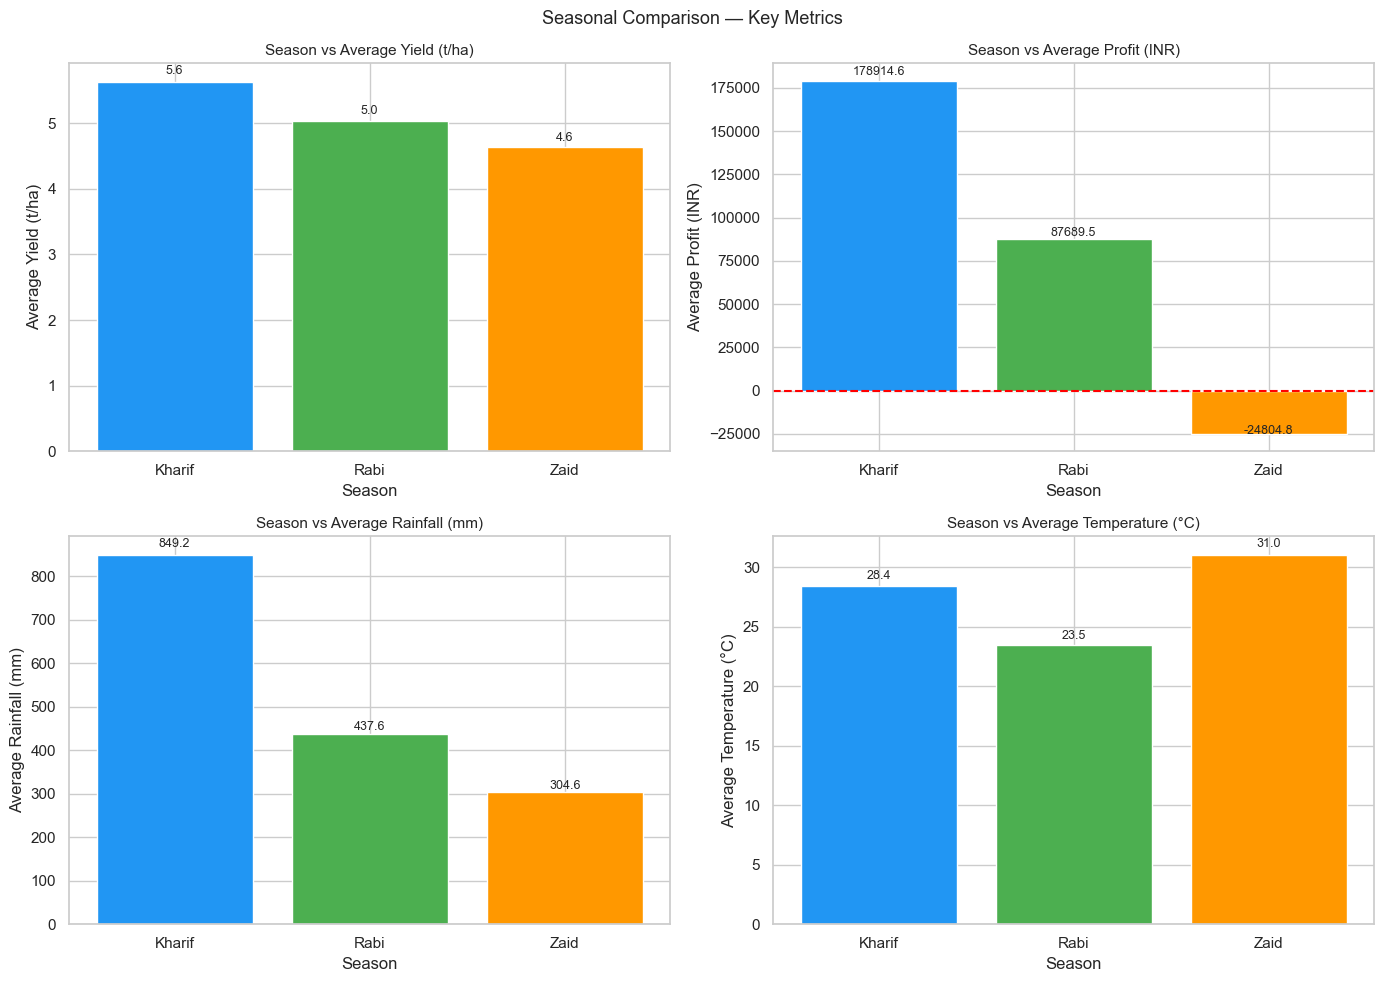

In [27]:
# 4 key metrics comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ["#2196F3", "#4CAF50", "#FF9800"]
metrics = {
    'Avg_Yield_t_ha': 'Average Yield (t/ha)',
    'Avg_Profit_INR': 'Average Profit (INR)',
    'Avg_Rainfall_mm': 'Average Rainfall (mm)',
    'Avg_Temperature_C': 'Average Temperature (°C)'
}
for ax, (col, label) in zip(axes.flatten(), metrics.items()):
    bars = ax.bar(season_metrics.index, season_metrics[col], color=colors)
    ax.set_title(f"Season vs {label}", fontsize=11)
    ax.set_xlabel("Season")
    ax.set_ylabel(label)
    if col == 'Avg_Profit_INR':
        ax.axhline(0, color='red', linestyle='--')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height()*1.02,
                f'{bar.get_height():.1f}',
                ha='center', fontsize=9)
plt.suptitle("Seasonal Comparison — Key Metrics", fontsize=13)
plt.tight_layout()
plt.show()

## 13. Student-Designed Analyses

Two additional analyses designed independently to investigate questions 
not covered in standard sections.

**Analysis 1:** Resource usage (Fertilizer & Water) by season  

**Analysis 2:** Which crop is most profitable in each season?  


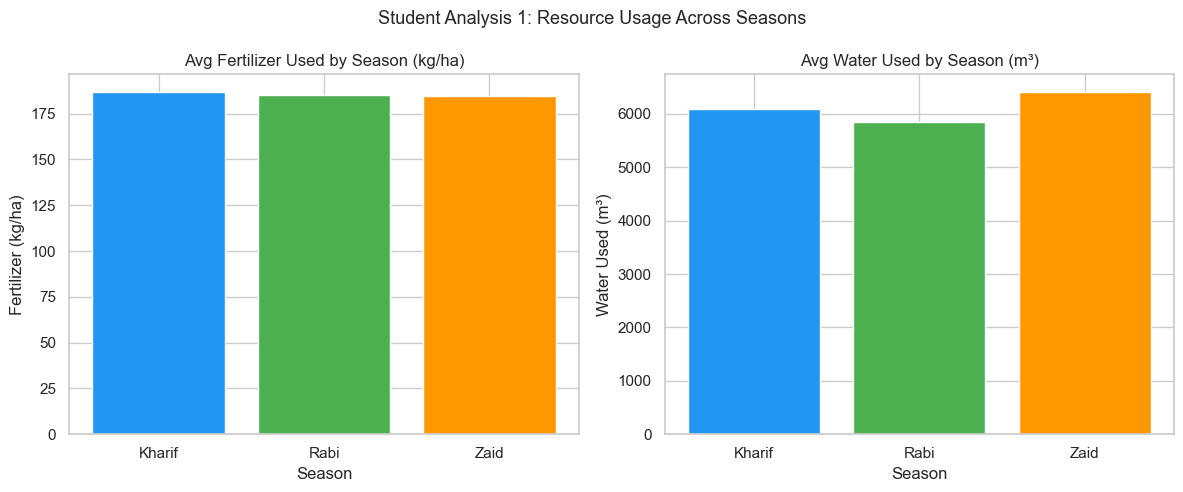

Fertilizer (kg/ha): {'Kharif': 187.08, 'Rabi': 185.41, 'Zaid': 184.64}
Water Used (m3): {'Kharif': 6102.2, 'Rabi': 5846.99, 'Zaid': 6419.89}


In [28]:
# Analysis 1: Fertilizer and Water usage by season
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Fertilizer
fert = df.groupby("Season")["Fertilizer_kg_ha"].mean()
axes[0].bar(fert.index, fert.values,
            color=["#2196F3", "#4CAF50", "#FF9800"])
axes[0].set_title("Avg Fertilizer Used by Season (kg/ha)", fontsize=12)
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Fertilizer (kg/ha)")

# Water
water = df.groupby("Season")["Water_Used_m3"].mean()
axes[1].bar(water.index, water.values,
            color=["#2196F3", "#4CAF50", "#FF9800"])
axes[1].set_title("Avg Water Used by Season (m³)", fontsize=12)
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Water Used (m³)")

plt.suptitle("Student Analysis 1: Resource Usage Across Seasons", fontsize=13)
plt.tight_layout()
plt.show()

print("Fertilizer (kg/ha):", fert.round(2).to_dict())
print("Water Used (m3):", water.round(2).to_dict())

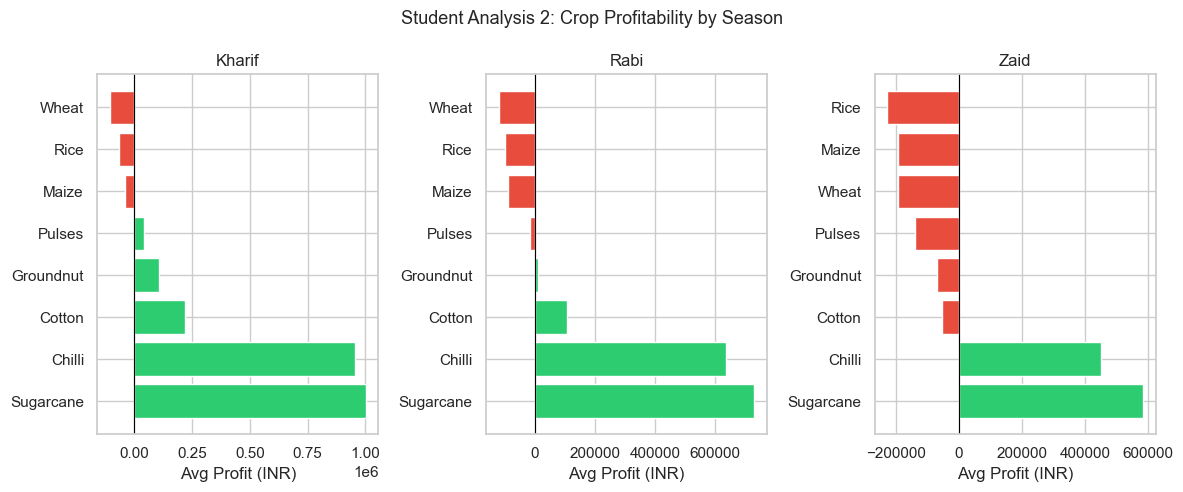

In [29]:
# Analysis 2: Most profitable crop per season
crop_profit = df.groupby(["Season", "Crop"])["Profit_INR"].mean().reset_index()

plt.figure(figsize=(12, 5))
for i, season in enumerate(["Kharif", "Rabi", "Zaid"]):
    plt.subplot(1, 3, i+1)
    data = crop_profit[crop_profit["Season"] == season].sort_values(
        "Profit_INR", ascending=False)
    colors_bar = ["#2ecc71" if x >= 0 else "#e74c3c" for x in data["Profit_INR"]]
    plt.barh(data["Crop"], data["Profit_INR"], color=colors_bar)
    plt.title(f"{season}", fontsize=12)
    plt.xlabel("Avg Profit (INR)")
    plt.axvline(0, color='black', linewidth=0.8)

plt.suptitle("Student Analysis 2: Crop Profitability by Season", fontsize=13)
plt.tight_layout()
plt.show()

## 14. Key Insights

---
### Insight 1: Kharif Season Has Highest Yield and Profit
**Observation:** Kharif records highest average yield (5.64 t/ha) and profit (₹1,78,914).  
**Evidence:** Seasonal comparison table + bivariate boxplots (Section 10, 12).  
**Interpretation:** Higher Kharif rainfall (852mm avg) supports better crop growth.  
**Limitation:** Crop type composition differs by season — this may also affect results.

---
### Insight 2: Zaid Season Average Profit Is Negative
**Observation:** Zaid average profit = –₹24,804. Farms lose money on average.  
**Evidence:** Profit boxplot shows Zaid median below zero break-even line.  
**Interpretation:** Low rainfall (299mm) + high temperature (31°C) increases costs and reduces yield.  
**Limitation:** Zaid has only 594 records — smaller sample may not represent full picture.

---
### Insight 3: Yield Decreases from Kharif → Rabi → Zaid
**Observation:** Avg yield: Kharif (5.64) > Rabi (5.08) > Zaid (4.67) t/ha.  
**Evidence:** Seasonal summary table (Section 7) and Section 10 boxplot.  
**Interpretation:** Higher rainfall seasons produce higher yields.  
**Limitation:** Different crops grown per season may partially explain yield differences.

---
### Insight 4: Rainfall Varies Dramatically Across Seasons
**Observation:** Kharif (852mm) vs Rabi (436mm) vs Zaid (299mm) — almost 3× difference.  
**Evidence:** Seasonal descriptive summary (Section 7) rainfall column.  
**Interpretation:** Rainfall availability is the primary environmental differentiator between seasons.  
**Limitation:** Irrigation supplements rainfall — not all farms are equally rain-dependent.

---
### Insight 5: Zaid Has Highest Average Temperature
**Observation:** Zaid avg temp = 31°C vs Kharif 28.4°C vs Rabi 23.5°C.  
**Evidence:** Season vs Temperature boxplot (Section 10).  
**Interpretation:** Heat stress in Zaid may contribute to lower yields.  
**Limitation:** Multiple variables affect yield — temperature alone is not the only cause.

---
### Insight 6: Kharif Season Uses Most Water and Fertilizer
**Observation:** Kharif farms use more water and fertilizer on average vs other seasons.  
**Evidence:** Student Analysis 1 bar charts (Section 13).  
**Interpretation:** Higher input use in Kharif may be justified by higher profit outcomes.  
**Limitation:** Farm size differences between seasons may influence total resource usage.

---
### Insight 7: Seasonal Yield Pattern Holds Across Most Indian States
**Observation:** Kharif > Rabi > Zaid yield pattern is consistent across most states.  
**Evidence:** State × Season heatmap (Section 11).  
**Interpretation:** Seasonal environmental patterns affect all regions similarly.  
**Limitation:** Some states show exceptions — this needs deeper state-level investigation.

---
### Insight 8: Missing Data Is Concentrated in Field-Measurement Columns
**Observation:** Only 3 columns have missing values: Rainfall_mm, Soil_Moisture_pct, Yield_Tonnes_Ha.  
**Evidence:** Missing value analysis using isnull().sum() (Section 7).  
**Interpretation:** These are measurement-dependent values, difficult to collect in remote farms.  
**Limitation:** Median imputation used may not represent true values in extreme weather records.

## 15. Recommendations

**Rec 1:** Prioritize Kharif for high-value crop investment — highest yield and profit confirmed.

**Rec 2:** Investigate Zaid loss causes before expanding — negative profit pattern visible in data.

**Rec 3:** Promote efficient irrigation in Rabi and Zaid — drip/sprinkler show better yield consistency.

**Rec 4:** Improve field data collection for Rainfall and Soil Moisture — 88 missing values found.

**Rec 5:** Apply state-specific strategies — heatmap shows some states perform differently from average.

**Rec 6:** Reduce fertilizer and water use in Zaid where profit is already negative — reduce input costs.

## 16. Conclusion

**What the dataset revealed:**
This analysis of 4,000 farm records across Kharif, Rabi, and Zaid seasons revealed 
clear seasonal differences in agricultural performance.

**Most important patterns:**
- Kharif outperforms all seasons in yield and profit
- Zaid shows negative average profit — a critical finding
- Rainfall is the strongest seasonal differentiator (852mm vs 299mm)
- Yield ranking: Kharif > Rabi > Zaid — consistent across most states

**Analytical findings:**
- Seasonal comparison table quantifies all key differences
- Correlation heatmap shows rainfall and soil moisture are positively associated with yield
- Resource usage (water, fertilizer) is highest in Kharif

**Limitations:**
- Association does not equal causation
- Zaid sample (594) is smaller than Kharif (1779) — affects reliability
- 120 values imputed with medians

**Future investigation:**
- Year-over-year time series would show if patterns are consistent
- Larger Zaid season dataset needed for confident conclusions
- Including input cost breakdown would improve economic analysis

## 17. Project Checklist

- [x] Dataset loaded successfully
- [x] Top 5 rows analyzed (head)
- [x] Dataset shape and structure examined
- [x] Data types examined
- [x] Missing values identified and handled
- [x] Duplicate records identified and handled
- [x] Descriptive/statistical analysis performed
- [x] Outliers investigated
- [x] Univariate analysis completed
- [x] Bivariate analysis completed
- [x] Multivariate analysis completed
- [x] Correlation analysis completed
- [x] Seasonal comparisons performed
- [x] At least 2 student-designed analyses completed
- [x] At least 8 key insights written
- [x] At least 5 recommendations provided
- [x] Conclusion written
- [x] All visualizations labeled (titles, axes, legends)
- [x] All key questions from problem statement answered